<a href="https://colab.research.google.com/github/jitiniqacsantosh/Project-4/blob/main/Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Import Important Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading the dataset**

In [ ]:
df = pd.read_excel('/content/Processed_Flipdata (1).xlsx')
df.sample(5)

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
362,376,itel A60,VertMenthe,32,2,5000,8MP,5MP,0,16.76,Unisoc,5999
42,42,SAMSUNG Galaxy F04,Jade Purple,64,4,5000,13MP,5MP,0,16.51,Mediatek Helio P35,7299
90,90,SAMSUNG Galaxy F14 5G,B.A.E. Purple,128,4,6000,50MP,13MP,0,16.76,"Exynos 1330, Octa Core",13490
231,231,realme Narzo 50,Speed Blue,128,6,5000,50MP,16MP,0,16.76,Mediatek Helio G96,12999
497,581,Infinix Hot 11,Emerald Green,64,4,5200,13MP,8MP,0,16.76,MediaTek Helio G70,9999


#***Summary***

This project is based on a dataset containing 541 rows and 12 columns that capture key features of mobile phones in today’s highly competitive market. The primary objective was to build an accurate predictive model for mobile phone prices. I began with comprehensive dataset exploration to understand the structure, feature distribution and data quality. This was followed by data preprocessing and detailed Exploratory Data Analysis (EDA) to clean the dataset and uncover meaningful patterns.

After gaining a clear understanding of the data, I performed feature extraction and applied statistical methods along with visualizations to identify the most influential factors affecting price. The dataset was then split into training and testing sets to build and validate the model. Model performance was evaluated using appropriate regression metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to measure prediction accuracy. Finally, I interpreted the results, extracted actionable insights and presented the overall performance and effectiveness of the predictive model.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB


In [ ]:
df.describe()

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height,Prize
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201,16228.375231
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553,10793.588322
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000,920.000000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000,9290.000000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000,13499.000000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000,19280.000000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000,80999.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

# Finding for cleaning dataset

Zero missing & duplicates values presented.
**After cleaning the data find 10 duplicates values**

unamed column is useless.

* '**Model**'
 1. Seprate company name and model
 2. The data is available in both lowercase and uppercase formats
 3. Some phone is 5G

* '**Color**'
 1. Same as above data is avaialble in both case formats
 2. 'M3' unknown word - check
* '**Memory**'
 1. Change column type, object into int64 to categorical type reduse the dataset memory usage

* '**Real Camera**' & ' **Front Camera**'
 1. change the column type into categocial
 2. Remove "MP" to convert column into number

* '**Mobile Height**'
 1. 2 Motorola phone have 41.94cm height; same company same processor, 128 GB Memory phn has around 16 cm height.

* '**Processor**'
 1. Use processor_Tier for convert this into ordinal data


In [ ]:
# Drop unnamed index column
df = df.drop('Unnamed: 0', axis=1)
display(df.head())

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [ ]:
# Split Company names to Model column
df['Company'] = df['Model'].apply(lambda x: x.split()[0])
df['Model'] = df['Model'].apply(lambda x: ' '.join(x.split()[1:]))
display(df.head())

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize,Company
0,SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Infinix
1,SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Infinix
2,G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999,MOTOROLA
3,C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649,POCO
4,HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999,Infinix


In [ ]:
# Remove MP in the cameras column and convert into interger Data type
df['Rear Camera'] = df['Rear Camera'].str.replace('MP', '', regex=False).astype(int)
df['Front Camera'] = df['Front Camera'].str.replace('MP', '', regex=False).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    object 
 1   Colour         541 non-null    object 
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    int64  
 6   Front Camera   541 non-null    int64  
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    object 
 10  Prize          541 non-null    int64  
 11  Company        541 non-null    object 
dtypes: float64(1), int64(7), object(4)
memory usage: 50.8+ KB


In [ ]:
# Convert to uppercase word to proper
df['Model'] = df['Model'].str.title()
df['Colour'] = df['Colour'].str.title()
df['Company'] = df['Company'].str.title()
df['Processor_'] = df['Processor_'].apply(lambda x: ' '.join([word.capitalize() for word in x.split()]))
display(df.head())

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize,Company
0,Smart 7,Night Black,64,4,6000,13,5,1,16.76,Unisoc Spreadtrum Sc9863a1,7299,Infinix
1,Smart 7,Azure Blue,64,4,6000,13,5,1,16.76,Unisoc Spreadtrum Sc9863a1,7299,Infinix
2,G32,Mineral Gray,128,8,5000,50,16,0,16.64,Qualcomm Snapdragon 680,11999,Motorola
3,C50,Royal Blue,32,2,5000,8,5,0,16.56,Mediatek Helio A22,5649,Poco
4,Hot 30I,Marigold,128,8,5000,50,5,1,16.76,G37,8999,Infinix


In [ ]:
# The value 41.94 in the Mobile Height column appears for the same phone model where another RAM variant shows 16.94.
# Therefore, this is not an outlier but a typing error, and the correct value should be 16.94.
df['Mobile Height'] = df['Mobile Height'].replace(41.94, 16.64)
df['Mobile Height'].unique()

array([16.76, 16.64, 16.56, 17.02, 16.51, 16.71, 17.04, 16.21, 16.94,
       16.33, 17.07,  4.5 ,  7.11, 16.26,  6.1 , 15.6 , 16.81,  5.08,
       16.59, 16.43, 16.66, 17.22, 16.36, 17.32, 15.46,  4.57, 16.54,
       15.49, 16.  , 15.7 , 16.69, 15.8 , 13.84, 17.53, 16.55, 17.65,
       12.7 ])

In [ ]:
# --- Processor tier (simple rule-based) ---
premium_chips = ['snapdragon 8', 'snapdragon 888', 'snapdragon 865', 'tensor g2',
                 'dimensity 8100', 'dimensity 1300', 'exynos 1380', 'dimensity 1080']
mid_chips     = ['snapdragon 6', 'snapdragon 7', 'snapdragon 695', 'dimensity 810',
                 'dimensity 900', 'dimensity 920', 'helio g96', 'helio g99', 'exynos 850']

def processor_tier(proc):
    if pd.isna(proc):
        return 0
    proc_l = str(proc).lower()
    if any(p in proc_l for p in premium_chips):
        return 2
    elif any(p in proc_l for p in mid_chips):
        return 1
    else:
        return 0

In [ ]:
df.sample(10)

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize,Company
57,G62 5G,Midnight Gray,128,6,5000,50,16,0,16.64,Qualcomm Snapdragon 695 5g,15499,Motorola
300,Y35,Dawn Gold,128,8,5000,50,16,0,16.71,Qualcomm Snapdragon 680,16999,Vivo
131,A1+,Light Green,32,2,5000,8,5,0,16.56,Mediatek Helio A22,6299,Redmi
458,Nord,Blue Marble,128,8,4115,48,13,0,16.36,Qualcommâ® Snapdragonâ_x0084_¢ 765g,24999,Oneplus
347,Spark 9T,Atlantic Blue,64,4,5000,50,8,0,16.76,Mediatek Helio G35,8649,Tecno
363,Y16,Drizzling Gold,64,4,5000,13,5,0,16.54,Mediatek Helio P35,11999,Vivo
485,Hot 12 Pro,Halo White,64,6,5000,50,8,0,16.76,Unisoc T616,9999,Infinix
330,Kall Z19Pro Flash Blue,Flash Blue,64,4,5000,13,8,0,16.51,Octa Core,7999,I
245,Mono,M3),16,4,1000,0,0,0,4.50,Mtk6261d,1699,Redmi
204,X5 Pro 5G,Horizon Blue,128,6,5000,108,16,0,16.94,Qualcomm Snapdragon 778g,21999,Poco


In [ ]:
# Detect 5G from Model or Processor
df['Is_5G'] = (df['Model'].str.contains('5G', na=False) | df['Processor_'].str.contains('5G|Dimensity [0-9]{3,4}(?! [A-Z])', na=False)).astype(int)

In [ ]:
df.sample(5)

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize,Company,Is_5G
99,M5,Power Black,128,6,5000,50,8,0,16.71,Mediatek Helio G99,14499,Poco,0
273,G32,Mineral Gray,64,4,5000,50,16,0,16.64,Qualcomm Snapdragon 680,10999,Motorola,0
512,V25 5G,Elegant Black,256,8,4500,64,50,0,16.36,Mediatek Dimensity 900,29418,Vivo,1
106,C50,Country Green,32,3,5000,8,5,0,16.56,Mediatek Helio A22,6299,Poco,0
210,T1 44W,Midnight Galaxy,128,8,5000,50,16,0,16.36,Qualcomm Snapdragon 680,17999,Vivo,0


In [ ]:
# Check missing values again
df.isnull().sum()

,0
Model,0
Colour,0
Memory,0
RAM,0
Battery_,0
Rear Camera,0
Front Camera,0
AI Lens,0
Mobile Height,0
Processor_,0


In [ ]:
# Check duplicates values again
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
# Remove obvious non-phone / feature-phone outliers
df = df[df['Battery_'] > 1000]
df = df[df['Mobile Height'] > 10]
df = df[df['Prize'] > 500]

In [ ]:
df.sample(10)

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize,Company,Is_5G
147,Note 12 5G,Mystique Blue,128,6,5000,48,13,0,16.94,Qualcomm Snapdragon 4 Gen 1,18999,Redmi,1
338,Kall Z19Pro,Blue,64,4,5000,13,8,0,16.51,Octa Core,7999,I,0
479,C31,Royal Blue,64,4,5000,13,5,0,16.59,Mediatek G35,8999,Poco,0
429,Y56 5G,Black Engine,128,4,5000,50,16,0,16.71,Mediatek Dimensity 700,17999,Vivo,1
318,Galaxy A14 5G,Black,128,6,5000,50,13,0,16.76,Sec S5e8535 (exynos 1330),18999,Samsung,1
320,Galaxy A14 5G,Light Green,128,6,5000,50,13,0,16.76,Sec S5e8535 (exynos 1330),18999,Samsung,1
402,Galaxy A14 5G,Dark Red,128,8,5000,50,13,0,16.76,Sec S5e8535 (exynos 1330),20999,Samsung,1
30,A1+,Light Blue,32,3,5000,8,5,0,16.56,Mediatek Helio A22,6599,Redmi,0
111,X5 5G,Supernova Green,128,6,5000,48,13,0,16.94,Qualcomm Snapdragon 695,15999,Poco,1
469,Narzo N55,Prime Black,64,4,5000,64,8,0,17.07,Mediatek Helio G88,11490,Realme,0


Based on the output, we can decide on a strategy to group or rename colors for standardization.

# Exploratory Data Analysis

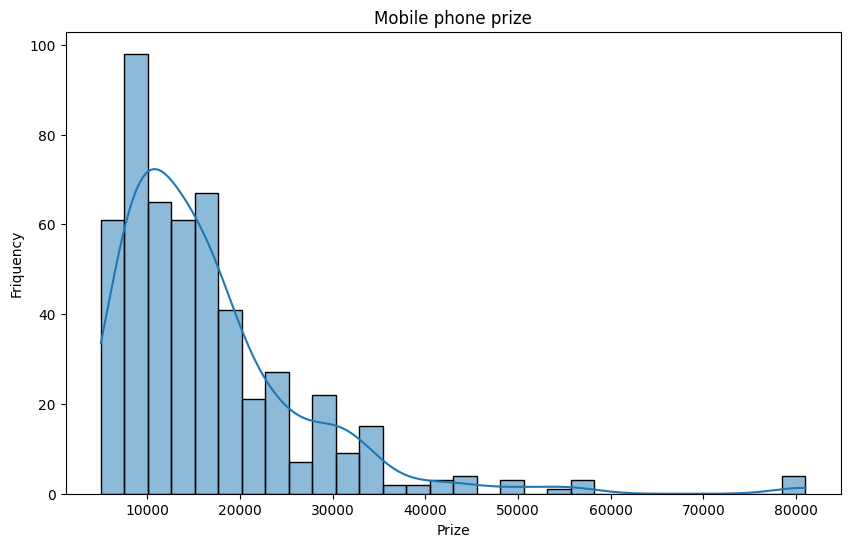

In [ ]:
# Phone Price Distribuiton
plt.figure(figsize=(10,6))
sns.histplot(df['Prize'], kde = True )
plt.title('Mobile phone prize')
plt.xlabel('Prize')
plt.ylabel('Friquency')
plt.show()

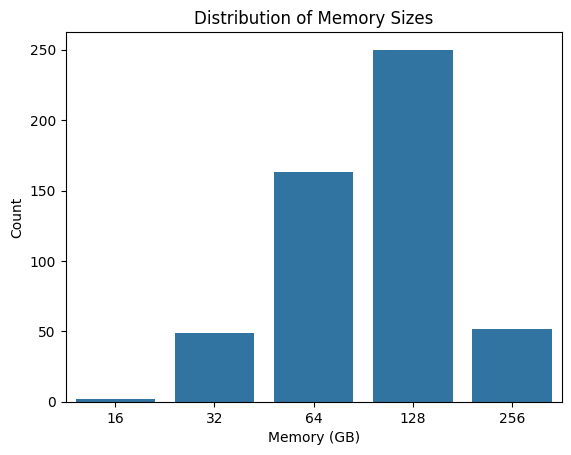

In [ ]:
sns.countplot(x='Memory' , data=df)
plt.title('Distribution of Memory Sizes')
plt.xlabel('Memory (GB)')
plt.ylabel('Count')
plt.show()

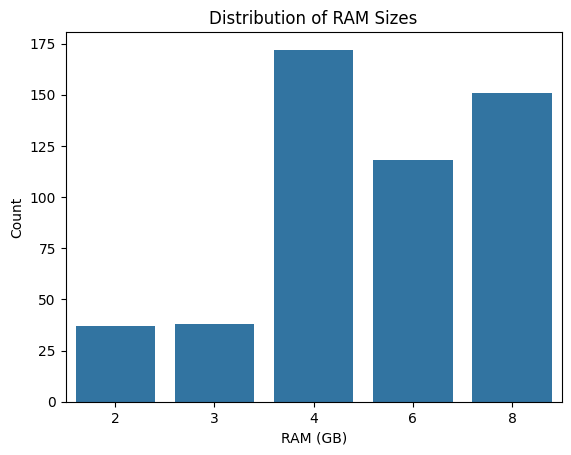

In [ ]:
sns.countplot(x='RAM', data = df)
plt.title('Distribution of RAM Sizes')
plt.xlabel('RAM (GB)')
plt.ylabel('Count')
plt.show()

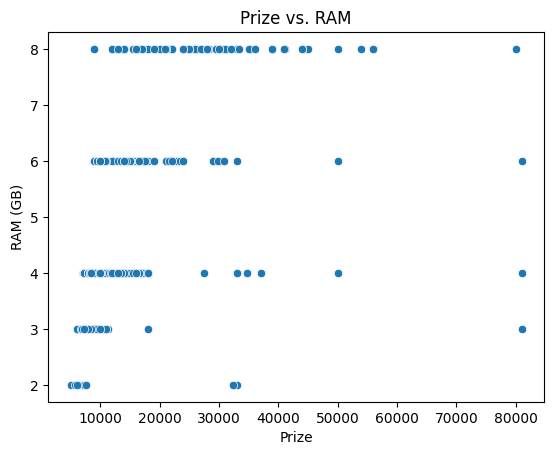

In [ ]:
sns.scatterplot(x = 'Prize', y='RAM', data = df)
plt.title('Prize vs. RAM')
plt.xlabel('Prize')
plt.ylabel('RAM (GB)')
plt.show()

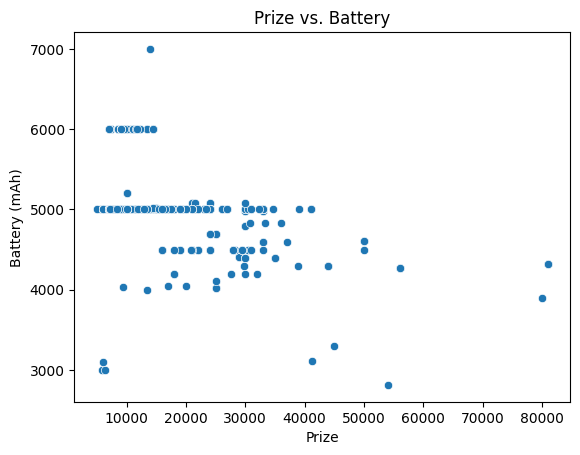

In [ ]:
sns.scatterplot(x = 'Prize' , y = 'Battery_' , data = df)
plt.title('Prize vs. Battery')
plt.xlabel('Prize')
plt.ylabel('Battery (mAh)')
plt.show()

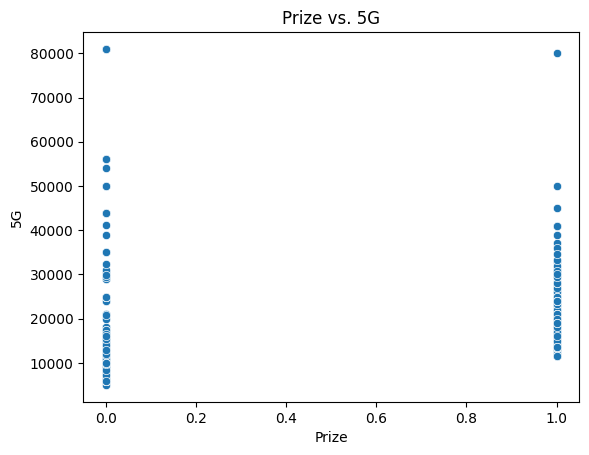

In [ ]:
sns.scatterplot(x='Is_5G' , y = 'Prize' , data = df)
plt.title('Prize vs. 5G')
plt.xlabel('Prize')
plt.ylabel('5G')
plt.show()

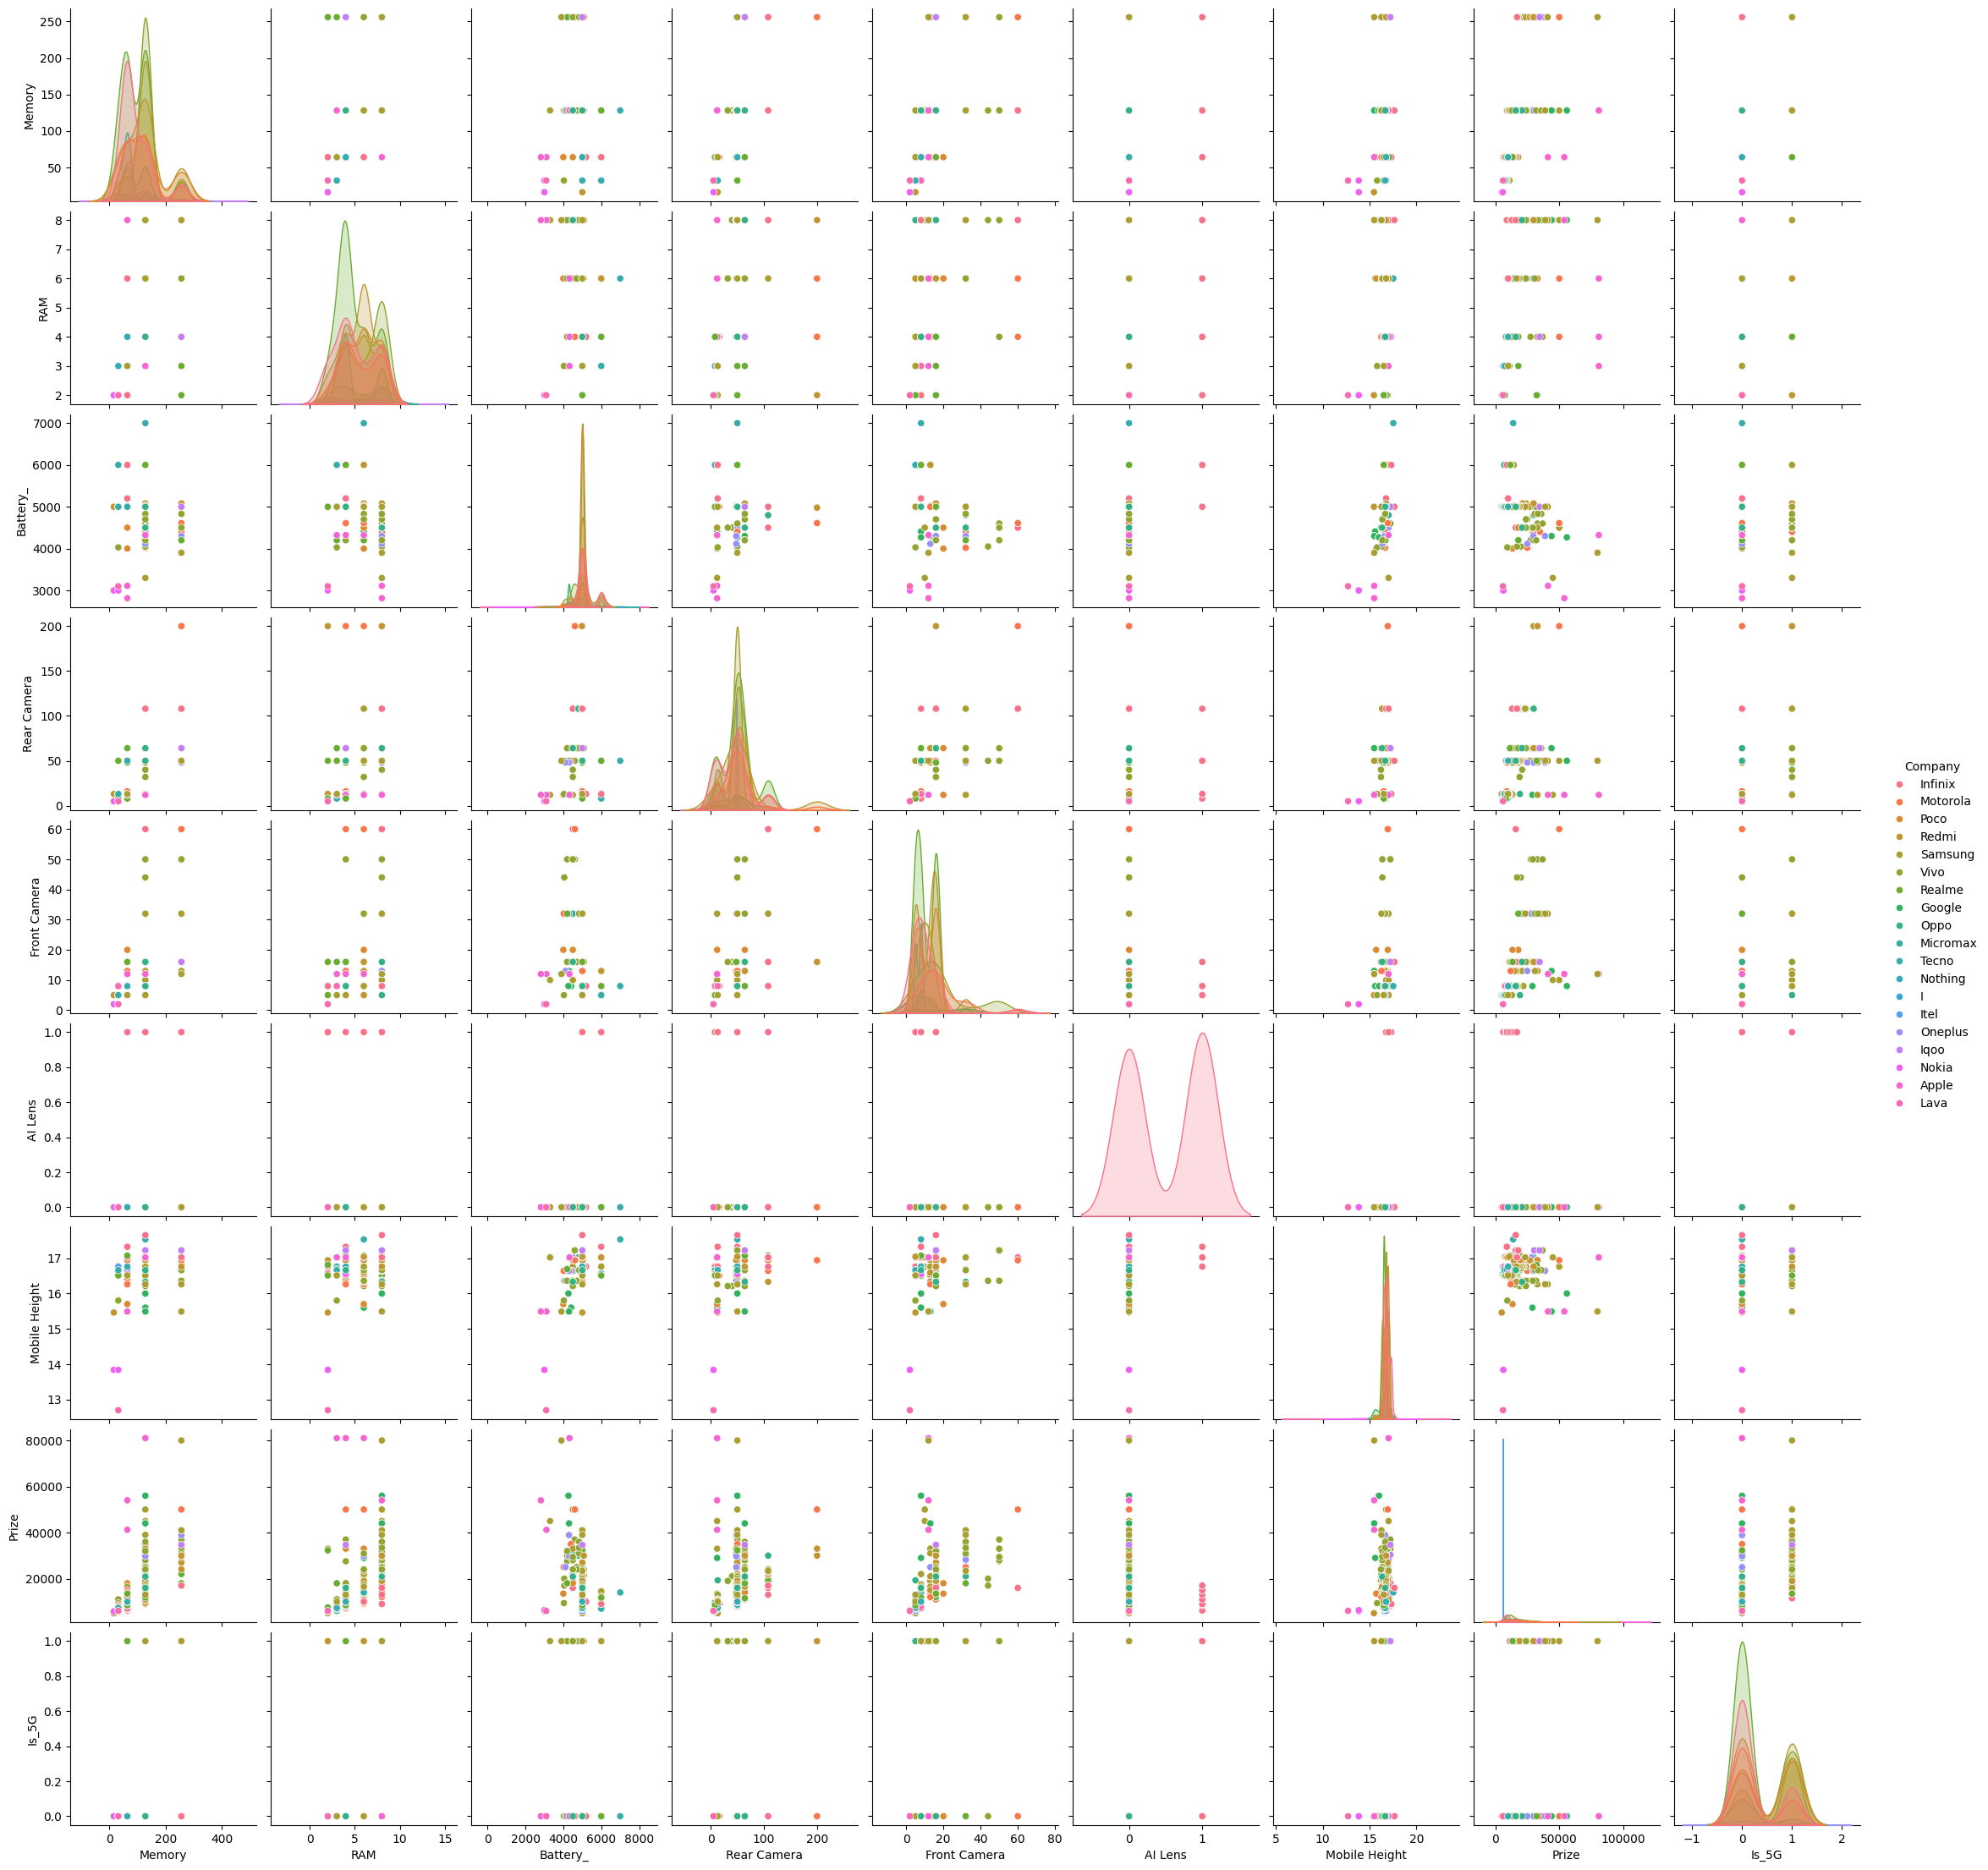

In [ ]:
sns.pairplot(df, hue = 'Company')
plt.show()

Text(0, 0.5, 'Prize')

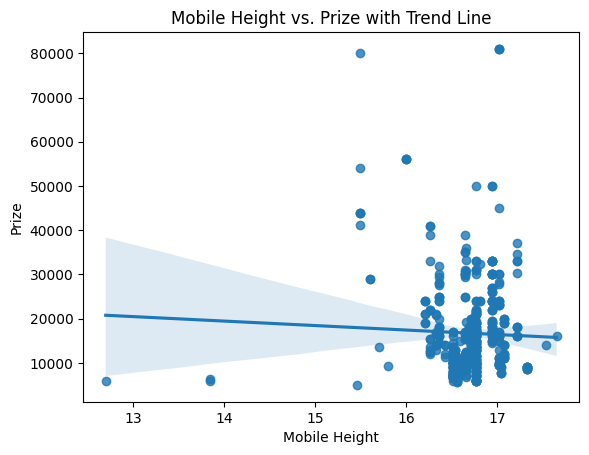

In [ ]:
sns.regplot(x='Mobile Height', y='Prize', data=df)
plt.title('Mobile Height vs. Prize with Trend Line')
plt.xlabel('Mobile Height')
plt.ylabel('Prize')

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 5.4 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df)
profile.to_file(output_file='porject.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 36.30it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

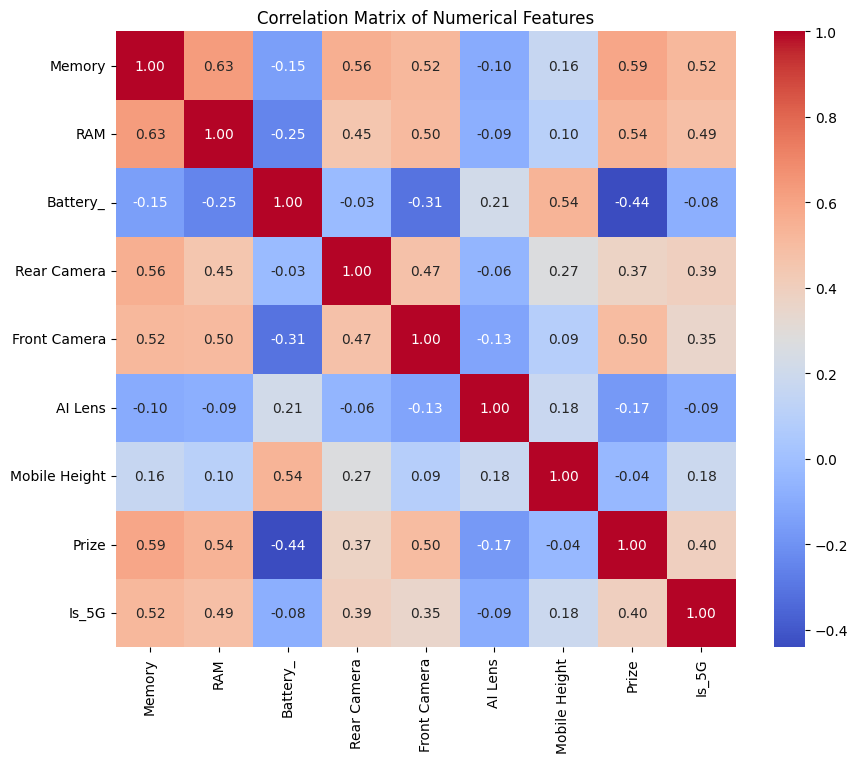

In [ ]:
# Create a heatmap of  numerical columns
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

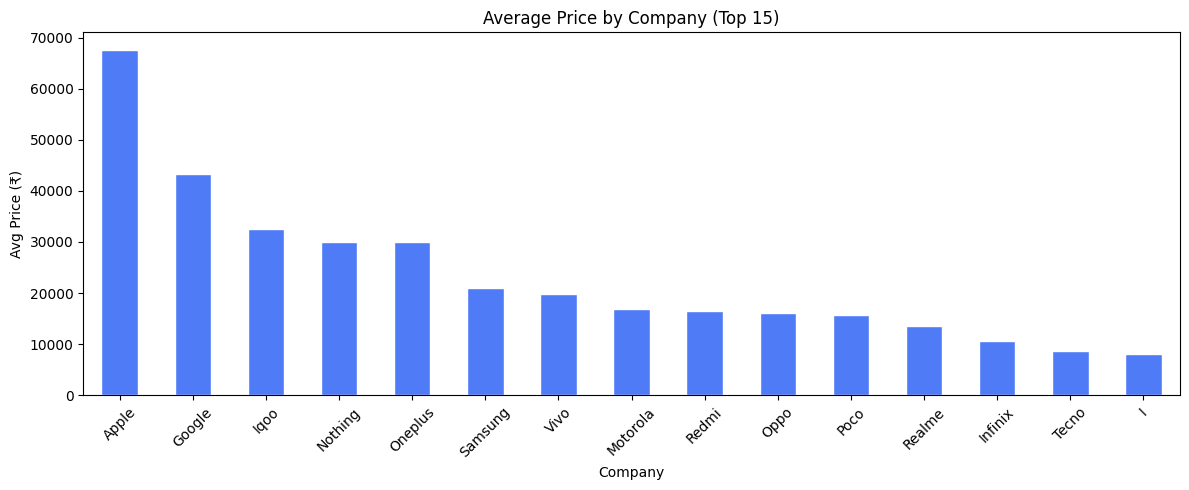

In [ ]:
# Brand average price
brand_price = df.groupby('Company')['Prize'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12,5))
brand_price.plot(kind='bar', color='#4F7BF7', edgecolor='white')
plt.title('Average Price by Company (Top 15)')
plt.ylabel('Avg Price (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('company_price.png', dpi=150)
plt.show()

# Feature Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 516 entries, 0 to 540
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          516 non-null    object 
 1   Colour         516 non-null    object 
 2   Memory         516 non-null    int64  
 3   RAM            516 non-null    int64  
 4   Battery_       516 non-null    int64  
 5   Rear Camera    516 non-null    int64  
 6   Front Camera   516 non-null    int64  
 7   AI Lens        516 non-null    int64  
 8   Mobile Height  516 non-null    float64
 9   Processor_     516 non-null    object 
 10  Prize          516 non-null    int64  
 11  Company        516 non-null    object 
 12  Is_5G          516 non-null    int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 72.6+ KB


Short the colour column for encoding processess

In [ ]:
color_mapping = {
    # Black variations
    'black': 'Black', 'power black': 'Black', 'midnight black': 'Black', 'starlight black': 'Black',
    'eclipse black': 'Black', 'cosmic black': 'Black', 'night black': 'Black', 'space black': 'Black',
    'carbon black': 'Black', 'dark black': 'Black', 'onyx black': 'Black', 'graphite black': 'Black',
    'matte black': 'Black', 'thunder black': 'Black', 'gravity black': 'Black', 'stealth black': 'Black',
    'fantasy black': 'Black', 'fusion black': 'Black', 'laser black': 'Black', 'diamond black': 'Black',
    'crystal black': 'Black', 'dynamic black': 'Black', 'quantum black': 'Black', 'velvet black': 'Black',
    'phantom black': 'Black', 'abyss black': 'Black', 'starry black': 'Black', 'mystic black': 'Black',
    'aurora black': 'Black', 'titan black': 'Black', 'twilight black': 'Black', 'eco black': 'Black',
    'forest black': 'Black', 'magic black': 'Black', 'moonlight black': 'Black', 'stellar black': 'Black',
    'cosmos black': 'Black', 'metal black': 'Black', 'obsidian black': 'Black', 'punk black': 'Black',
    'mirror black': 'Black', 'vibrant black': 'Black', 'prism black': 'Black', 'infinite black': 'Black',
    'shadow black': 'Black', 'glimmer black': 'Black', 'nightsky black': 'Black', 'denim black': 'Black',
    'flashy black': 'Black', 'force black': 'Black', 'omg black': 'Black', 'ink black': 'Black',
    'jaguar black': 'Black', 'rush black': 'Black', 'racing black': 'Black', 'steel black': 'Black',
    'charcoal black': 'Black', 'prime black': 'Black', 'flash black': 'Black', 'turbo black': 'Black',
    'pure black': 'Black', 'noble black': 'Black', 'speed black': 'Black', 'astral black': 'Black',
    'lunar black': 'Black', 'cross black': 'Black', 'submariner black': 'Black', 'meteor black': 'Black',
    'supersonic black': 'Black', 'cyber black': 'Black', 'agate black': 'Black', 'infinity black': 'Black',
    'steller black': 'Black', 'glowing black': 'Black', 'endless black': 'Black', 'stardust black': 'Black',
    'interstellar black': 'Black', 'black engine': 'Black', 'elegant black': 'Black',

    # Blue variations
    'blue': 'Blue', 'cool blue': 'Blue', 'sky blue': 'Blue', 'light blue': 'Blue', 'ocean blue': 'Blue',
    'electric blue': 'Blue', 'arctic blue': 'Blue', 'starry blue': 'Blue', 'wave blue': 'Blue',
    'aqua blue': 'Blue', 'glacier blue': 'Blue', 'ice blue': 'Blue', 'deep blue': 'Blue', 'navy blue': 'Blue',
    'cloud blue': 'Blue', 'denim blue': 'Blue', 'sea blue': 'Blue', 'azure blue': 'Blue', 'magic blue': 'Blue',
    'dynamic blue': 'Blue', 'aqua sky': 'Blue', 'mint blue': 'Blue', 'velocity wave': 'Blue',
    'royal blue': 'Blue', 'waterfall blue': 'Blue', 'marine blue': 'Blue', 'frosted blue': 'Blue',
    'midnight blue': 'Blue', 'night sea': 'Blue', 'lake blue': 'Blue', 'wildcat blue': 'Blue',
    'icy blue': 'Blue', 'nebula blue': 'Blue', 'pacific blue': 'Blue', 'silk blue': 'Blue',
    'racing blue': 'Blue', 'space blue': 'Blue', 'dark blue': 'Blue', 'horizon blue': 'Blue',
    'origin blue': 'Blue', 'soulful blue': 'Blue', 'iceberg blue': 'Blue', 'baby blue': 'Blue',
    'luna blue': 'Blue', 'watery blue': 'Blue', 'exploratory blue': 'Blue', 'lunar blue': 'Blue',
    'sunrise blue': 'Blue', 'polar blue': 'Blue', 'atlantis blue': 'Blue', 'flash blue': 'Blue',
    'atlantic blue': 'Blue', 'phantom blue': 'Blue', 'prism blue': 'Blue', 'prime blue': 'Blue',
    'stripe blue': 'Blue', 'laser blue': 'Blue', 'steel blue': 'Blue', 'oxygen blue': 'Blue',
    'surfing blue': 'Blue', 'aurora blue': 'Blue', 'blue marble': 'Blue', 'deep ocean blue': 'Blue',
    'sailing blue': 'Blue', 'tuscany blue': 'Blue', 'aquamarine blue': 'Blue', 'dawnblue': 'Blue', 'heart of ocean': 'Blue', 'deepsea luster': 'Blue', 'sky mirror': 'Blue',

    # White variations
    'white': 'White', 'starlight white': 'White', 'pearl white': 'White', 'snowfall': 'White',
    'ceramic white': 'White', 'lunar white': 'White', 'polar white': 'White', 'dream white': 'White',
    'diamond white': 'White', 'star white': 'White', 'pure white': 'White', 'light white': 'White',
    'creamy white': 'White', 'lucent white': 'White', 'jade white': 'White', 'alpine white': 'White',
    'paper white': 'White', 'clash white': 'White', 'snowstorm white': 'White', 'arctic white': 'White',
    'white lily': 'White', 'glacier white': 'White', 'halo white': 'White', 'astral white': 'White',
    'metallic white': 'White', 'stardust white': 'White', 'frost white': 'White', 'snow': 'White', 'pearly white': 'White',

    # Green variations
    'green': 'Green', 'green apple': 'Green', 'mint green': 'Green', 'bamboo green': 'Green',
    'forest green': 'Green', 'jade green': 'Green', 'aqua green': 'Green', 'country green': 'Green',
    'olive green': 'Green', 'emerald green': 'Green', 'arctic green': 'Green', 'pine green': 'Green',
    'awesome green': 'Green', 'lively green': 'Green', 'mint': 'Green', 'lime green': 'Green',
    'fantasy green': 'Green', 'opal green': 'Green', 'light green': 'Green', 'caribbean green': 'Green',
    'goat green': 'Green', 'rainforest': 'Green', 'supernova green': 'Green', 'blaster green': 'Green',
    'frosted green': 'Green', 'nebula green': 'Green', 'coral green': 'Green', 'atlantic green': 'Green',
    'dark green': 'Green', 'aurora green': 'Green', 'playful green': 'Green', 'green fantasy': 'Green',
    'glacial green': 'Green', 'lightsaber green': 'Green', 'oxygen green': 'Green', 'awesome lime': 'Green',
    'light sea green': 'Green', 'jade fog': 'Green', 'vertmenthe': 'Green', 'lemongrass': 'Green',

    # Red variations
    'red': 'Red', 'scarlet red': 'Red', 'fire red': 'Red', 'sunset red': 'Red', 'fiery red': 'Red',
    'flame red': 'Red', 'vibrant red': 'Red', 'lava red': 'Red', 'dark red': 'Red',

    # Gold variations
    'gold': 'Gold', 'twilight gold': 'Gold', 'champagne gold': 'Gold', 'rose gold': 'Gold', 'fancy gold': 'Gold',
    'glitter gold': 'Gold', 'aurora gold': 'Gold', 'sandy gold': 'Gold', 'sunrise gold': 'Gold',
    'drizzling gold': 'Gold', 'tahiti gold': 'Gold', 'dawn gold': 'Gold', 'solar gold': 'Gold',
    'sunshine gold': 'Gold', 'metallica gold': 'Gold',

    # Silver variations
    'silver': 'Silver', 'light silver': 'Silver', 'aura silver': 'Silver', 'glacier silver': 'Silver',
    'moonlight silver': 'Silver', 'frost silver': 'Silver', 'satin silver': 'Silver', 'blade silver': 'Silver',
    'racing silver': 'Silver', 'quick silver': 'Silver', 'awesome silver': 'Silver', 'silver wave': 'Silver',

    # Gray variations
    'grey': 'Gray', 'gray': 'Gray', 'mineral gray': 'Gray', 'cosmic grey': 'Gray', 'graphite gray': 'Gray',
    'space gray': 'Gray', 'dark gray': 'Gray', 'steel grey': 'Gray', 'midnight gray': 'Gray',
    'watery grey': 'Gray', 'carbon gray': 'Gray', 'meterorite grey': 'Gray', 'meteor grey': 'Gray',
    'shadow gray': 'Gray', 'awesome graphite': 'Gray', 'slate grey': 'Gray', 'volcanic grey': 'Gray',
    'mithril grey': 'Gray', 'cool grey': 'Gray', 'charcoal': 'Gray', 'charcoal grey': 'Gray',

    # Yellow variations
    'yellow': 'Yellow', 'prism yellow': 'Yellow', 'vibrant yellow': 'Yellow', 'marigold': 'Yellow',

    # Pink variations
    'pink': 'Pink', 'pastel pink': 'Pink', 'blush pink': 'Pink', 'peach pink': 'Pink', 'metallic rose': 'Pink',

    # Purple variations
    'purple': 'Purple', 'awesome violet': 'Purple', 'lavender': 'Purple', 'mystic purple': 'Purple',
    'iris purple': 'Purple', 'violet': 'Purple', 'fantasy purple': 'Purple', 'jade purple': 'Purple',
    'b.a.e. purple': 'Purple', 'peppy purple': 'Purple', 'space purple': 'Purple', 'stardust purple': 'Purple',
    '7° purple': 'Purple', 'starry purple': 'Purple', 'nebula purple': 'Purple',

    # Orange variations
    'orange': 'Orange', 'sunrise orange': 'Orange', 'coral orange': 'Orange', 'sunlight orange': 'Orange',
    'sunset orange': 'Orange', 'orange shimmer': 'Orange',

    # Other distinct colors/types
    'brown': 'Brown',
    'cream': 'Cream',
    'cyan': 'Cyan', 'turquoise cyan': 'Cyan', 'turbo cyan': 'Cyan',
    'beige': 'Beige',
    'transparent': 'Transparent',
    'multi color': 'Multi Color',
    'aurora': 'Aurora',
    'stardust': 'Stardust',
    'rainbow': 'Rainbow',
    'lava': 'Lava',
    'ice': 'Ice', 'ice dawn': 'Ice',
    'dream': 'Dream',
    'fantasy': 'Fantasy',
    'magnetic': 'Magnetic',
    'cosmic': 'Cosmic',
    'liquid': 'Liquid',
    'misty': 'Misty',
    'dawn': 'Dawn',
    'midnight': 'Midnight',
    'glacier': 'Glacier',
    'ocean': 'Ocean',
    'nebula': 'Nebula',
    'starry': 'Starry', 'starry sky': 'Starry',
    'cloud': 'Cloud',
    'sunlight': 'Sunlight',
    'forest': 'Forest',
    'silver streak': 'Silver',
    'gold streak': 'Gold',
    'blue streak': 'Blue',
    'red streak': 'Red',
    'green streak': 'Green',
    'yellow streak': 'Yellow',
    'copper blush': 'Copper',
    'sunrise copper': 'Copper',
    'copper': 'Copper',
    'sapphireblack': 'Black',
    'm3)': 'Unknown' # Appears to be an outlier or mistyped, mapping to 'Unknown'
}

def standardize_colour_name(colour):
    # Ensure string and strip whitespace before converting to lower and looking up
    if pd.isna(colour):
        return colour
    standardized_key = str(colour).strip().lower()
    return color_mapping.get(standardized_key, colour)

df['Colour'] = df['Colour'].apply(standardize_colour_name)

In [ ]:
color_counts = df['Colour'].value_counts()
low_frequency_colors = color_counts[color_counts < 10].index
df['Colour'] = df['Colour'].replace(low_frequency_colors, 'Other')

In [ ]:
print(df['Colour'].value_counts())

Colour
Blue      127
Black     123
Other      83
Green      56
White      31
Gray       23
Gold       19
Purple     17
Yellow     14
Silver     13
Orange     10
Name: count, dtype: int64


Based on the output, we can decide on a strategy to group or rename colors for standardization.

In [ ]:
#
df['Company'].value_counts()

,count
Company,
Realme,97
Redmi,71
Infinix,65
Vivo,60
Poco,58
Samsung,53
Motorola,45
Oppo,16
Tecno,16


In [ ]:
#
Company_counts = df['Company'].value_counts()
low_frequency_company = Company_counts[Company_counts < 10].index
df['Company'] = df['Company'].replace(low_frequency_company, 'Other')
df['Company'].value_counts()


,count
Company,
Realme,97
Redmi,71
Infinix,65
Vivo,60
Poco,58
Samsung,53
Motorola,45
Other,35
Oppo,16


In [ ]:
df['Processor_'].value_counts()
#

,count
Processor_,
Qualcomm Snapdragon 680,33
Mediatek Helio A22,21
Unisoc T612,21
Mediatek Helio P35,19
Mediatek Dimensity 1080,18
...,...
6 Core,1
Dimensity 8200,1
Qualcomm Sm6225 Snapdragon 680 4g (6 Nm),1


# Task
Apply the `processor_tier` function to the 'Processor_' column of the DataFrame `df` to create a new 'Processor_Tier' column, then display the value counts of 'Processor_Tier' and a sample of the DataFrame to confirm the changes.

## Apply Processor Tier

### Subtask:
Apply the predefined `processor_tier` function to the 'Processor_' column to create a new 'Processor_Tier' column, classifying processors into numerical tiers.


**Reasoning**:
Apply the predefined `processor_tier` function to the 'Processor_' column to create a new 'Processor_Tier' column, then display its value counts and a sample of the DataFrame as per the instructions.



In [ ]:
df['Processor_Tier'] = df['Processor_'].apply(processor_tier)
print(df['Processor_Tier'].value_counts())
display(df.sample(5))

Processor_Tier
0    272
1    180
2     64
Name: count, dtype: int64


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize,Company,Is_5G,Processor_Tier
45,Galaxy F13,Other,128,4,6000,50,8,0,16.76,Exynos 850,10699,Samsung,0,1
107,Narzo 30 Pro 5G,Silver,128,8,5000,48,16,0,16.51,Mediatek Dimensity 800u,15999,Realme,1,0
145,Note 12 5G,Green,128,6,5000,48,13,0,16.94,Qualcomm Snapdragon 4 Gen 1,18999,Redmi,1,0
458,Nord,Blue,128,8,4115,48,13,0,16.36,Qualcommâ® Snapdragonâ_x0084_¢ 765g,24999,Other,0,0
200,X5 5G,Blue,256,8,5000,48,13,0,16.94,Qualcomm Snapdragon 695,17999,Poco,1,1


## Final Task

### Subtask:
Confirm the successful processing of the 'Processor_' column and ask for further instructions.


## Summary:

### Data Analysis Key Findings
*   A new column named 'Processor\_Tier' was successfully added to the DataFrame by applying the `processor_tier` function to the 'Processor\_' column.
*   The distribution of processor tiers is as follows: Tier 0 has 272 entries, Tier 1 has 180 entries, and Tier 2 has 64 entries.

### Insights or Next Steps
*   The 'Processor\_Tier' column provides a standardized categorization of processor performance, enabling easier comparison and analysis of devices based on their processing power.
*   The next step could involve analyzing the correlation between 'Processor\_Tier' and other performance metrics or device characteristics, or using this new column for segmentation in further analysis.


In [ ]:
df['Processor_Tier'].value_counts()

,count
Processor_Tier,
0,272
1,180
2,64


In [ ]:
# Drop Processor_ and Model column
df  = df.drop(['Processor_', 'Model'], axis=1)
df

,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Prize,Company,Is_5G,Processor_Tier
0,Black,64,4,6000,13,5,1,16.76,7299,Infinix,0,0
1,Blue,64,4,6000,13,5,1,16.76,7299,Infinix,0,0
2,Gray,128,8,5000,50,16,0,16.64,11999,Motorola,0,1
3,Blue,32,2,5000,8,5,0,16.56,5649,Poco,0,0
4,Yellow,128,8,5000,50,5,1,16.76,8999,Infinix,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
536,Other,256,8,3900,50,12,0,15.49,79999,Samsung,1,2
537,Other,32,2,3100,5,2,0,12.70,5998,Other,0,0
538,Other,64,4,5000,50,8,0,16.76,9990,Tecno,0,0
539,Green,128,8,5000,50,32,0,16.26,38999,Samsung,1,2


In [ ]:
# Import more required Libraries
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split , cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import  LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import re

In [ ]:
# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Prize']), df['Prize'],test_size = 0.2)

In [ ]:
X_train.head()

,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Company,Is_5G,Processor_Tier
63,Gold,128,4,5000,50,5,0,16.51,Realme,0,0
11,Blue,64,4,5000,50,5,1,16.76,Infinix,0,0
483,Other,64,4,5000,13,5,0,16.66,Tecno,0,0
272,Blue,256,4,4980,200,16,0,16.94,Redmi,1,2
260,Green,256,8,4500,50,16,0,16.26,Realme,1,1


In [ ]:
# One Hot Encoding
trf1 = ColumnTransformer([
  ('ohe_Comapany_Colour',OneHotEncoder(sparse_output=False, drop='first'), ['Company', 'Colour'])
], remainder='passthrough')

In [ ]:
# Combined Transformer for Ordinal Encoding and Scaling
# Output of trf1 has 28 columns:
# Indices 0-18: OHE columns (from Company and Colour) (19 columns)
# Index 19: Memory
# Index 20: RAM
# Index 21: Battery_
# Index 22: Rear Camera
# Index 23: Front Camera
# Index 24: AI Lens
# Index 25: Mobile Height
# Index 26: Is_5G
# Index 27: Processor_Tier

# Define the indices for scaling, ordinal encoding, and implicit passthrough
scale_cols = [19, 20, 21, 22, 23, 25]  # Memory, RAM, Battery_, Rear Camera, Front Camera, Mobile Height
ordinal_cols = [27]  # Processor_Tier

trf_numerical_processing = ColumnTransformer(
    [
        ('scale', MinMaxScaler(), scale_cols),
        ('ordinal_processor_tier', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
    ],
    remainder='passthrough' # Passes through OHE columns, AI Lens, and Is_5G
)

In [ ]:
# This transformer is no longer needed as its functionality is merged into trf_numerical_processing

In [ ]:
# train the model
trf4 = LinearRegression()

# Create the pipeline

In [ ]:
pipe = Pipeline([
    ('trf1', trf1),
    ('trf_numerical_processing', trf_numerical_processing),
    ('trf4', trf4)
])

In [ ]:
# train model
pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_Comapany_Colour',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Company', 'Colour'])])),
                ('trf_numerical_processing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_encoding',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  [27]),
                                                 ('scale', MinMaxScaler(),
                                                  [19, 20, 21, 22, 23, 25])])),
                ('trf4', LinearRegression())])

In [ ]:
# Create a preprocessor pipeline from the existing transformers
preprocessor_pipe = Pipeline([
    ('trf1', trf1),
    ('trf_numerical_processing', trf_numerical_processing)
])

# Transform the training and testing data using the preprocessor
X_train_preprocessed = preprocessor_pipe.fit_transform(X_train)
X_test_preprocessed = preprocessor_pipe.transform(X_test)

models = {
    'Linear Regression'       : LinearRegression(),
    'Ridge Regression'        : Ridge(alpha=10),
    'Decision Tree'           : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'           : RandomForestRegressor(n_estimators=200, max_depth=12,
                                                      random_state=42, n_jobs=-1),
    'Gradient Boosting'       : GradientBoostingRegressor(n_estimators=300, max_depth=5,
                                                          learning_rate=0.05, random_state=42),
}

results = {}
for name, model in models.items():
    # Fit models on preprocessed data
    model.fit(X_train_preprocessed, y_train)
    # Make predictions on preprocessed test data
    preds = model.predict(X_test_preprocessed)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    # Perform cross-validation on preprocessed training data
    cv    = cross_val_score(model, X_train_preprocessed, y_train, cv=5, scoring='r2').mean()
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'CV R²': cv}
    print(f"{name:25s} | MAE: {mae:>8,.0f} | RMSE: {rmse:>9,.0f} | R²: {r2:.4f} | CV R²: {cv:.4f}")

results_df = pd.DataFrame(results).T
print("\n", results_df)


Linear Regression         | MAE:    4,098 | RMSE:     5,790 | R²: 0.5324 | CV R²: 0.5865
Ridge Regression          | MAE:    3,447 | RMSE:     4,838 | R²: 0.6735 | CV R²: 0.5706
Decision Tree             | MAE:    2,327 | RMSE:     5,685 | R²: 0.5492 | CV R²: 0.7864
Random Forest             | MAE:    1,949 | RMSE:     4,008 | R²: 0.7759 | CV R²: 0.8838
Gradient Boosting         | MAE:    1,905 | RMSE:     4,380 | R²: 0.7324 | CV R²: 0.8648

                            MAE         RMSE        R²     CV R²
Linear Regression  4097.726175  5789.985564  0.532376  0.586532
Ridge Regression   3447.046309  4838.123058  0.673491  0.570631
Decision Tree      2327.232425  5684.740466  0.549222  0.786379
Random Forest      1948.711644  4008.272535  0.775893  0.883848
Gradient Boosting  1904.560407  4380.000216  0.732398  0.864819


#Insights -

The feature importance analysis using the Random Forest model has been successfully completed and visualized. Here are the top features influencing mobile phone prices:

**Battery_:** This is by far the most important feature, with an importance score of approximately 0.349.

**Front Camera:** The front camera megapixels are also highly influential, with an importance score of around 0.248.

**Memory:** The internal memory size is another significant factor, with an importance score of about 0.091.

**Processor_Tier:** The processor tier, which categorizes the processor's performance, also has a notable impact, with an importance score of about 0.091.

**Mobile Height:** The physical height of the mobile contributes with an importance of around 0.052.
**Is_5G**: Whether the phone supports 5G connectivity is also a moderately important feature, with an importance of around 0.047.
Other features like Rear Camera, RAM, and certain Colour and Company categories have lower but still contributing importance scores. This analysis helps understand which phone specifications are most critical in determining its price according to this model.


#Best Model - Feature Importance

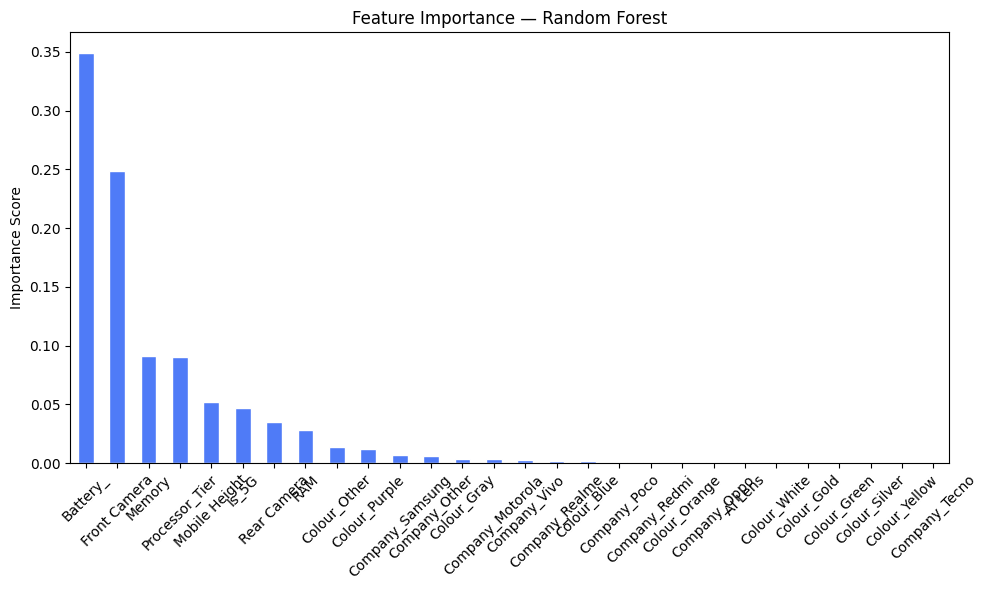


Top Features:
 Battery_            0.349112
Front Camera        0.248260
Memory              0.090833
Processor_Tier      0.090613
Mobile Height       0.052062
Is_5G               0.047004
Rear Camera         0.034985
RAM                 0.028314
Colour_Other        0.014048
Colour_Purple       0.012280
Company_Samsung     0.007115
Company_Other       0.005786
Colour_Gray         0.003574
Company_Motorola    0.003145
Company_Vivo        0.002188
Company_Realme      0.001833
Colour_Blue         0.001722
Company_Poco        0.001300
Company_Redmi       0.001102
Colour_Orange       0.001076
Company_Oppo        0.001000
AI Lens             0.000802
Colour_White        0.000487
Colour_Gold         0.000474
Colour_Green        0.000465
Colour_Silver       0.000208
Colour_Yellow       0.000158
Company_Tecno       0.000052
dtype: float64


In [ ]:
best_model = models['Random Forest']    # typically best performer
importances = best_model.feature_importances_

# --- Construct the 'features' list to match the order of X_train_preprocessed ---

# Get feature names after trf1 (OneHotEncoder for Company/Colour + passthrough)
# trf1's OHE part
ohe_company_colour_names = preprocessor_pipe.named_steps['trf1'].named_transformers_['ohe_Comapany_Colour'].get_feature_names_out(input_features=['Company', 'Colour'])
# trf1's remainder part (original columns that were not 'Company' or 'Colour')
remaining_X_train_cols = [col for col in X_train.columns if col not in ['Company', 'Colour']]
features_after_trf1_transform = list(ohe_company_colour_names) + remaining_X_train_cols

# Define the order of features after trf_numerical_processing
final_features = []

# 1. Features processed by 'scale' (MinMaxScaler)
scale_cols_names_at_trf1_output = ['Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'Mobile Height']
for col_name in scale_cols_names_at_trf1_output:
    final_features.append(col_name)

# 2. Features processed by 'ordinal_processor_tier' (OrdinalEncoder)
ordinal_cols_names_at_trf1_output = ['Processor_Tier']
for col_name in ordinal_cols_names_at_trf1_output:
    final_features.append(col_name)

# 3. Features passed through by 'remainder=passthrough' in trf_numerical_processing
# These are the OHE features from trf1, plus 'AI Lens' and 'Is_5G'
explicitly_transformed_by_numerical_processing = set(scale_cols_names_at_trf1_output + ordinal_cols_names_at_trf1_output)
for col_name in features_after_trf1_transform:
    if col_name not in explicitly_transformed_by_numerical_processing:
        final_features.append(col_name)

features = final_features

# --- End of 'features' list construction ---

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar', color='#4F7BF7', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop Features:\n", feat_imp)

#ACTUAL vs PREDICTED PLOT

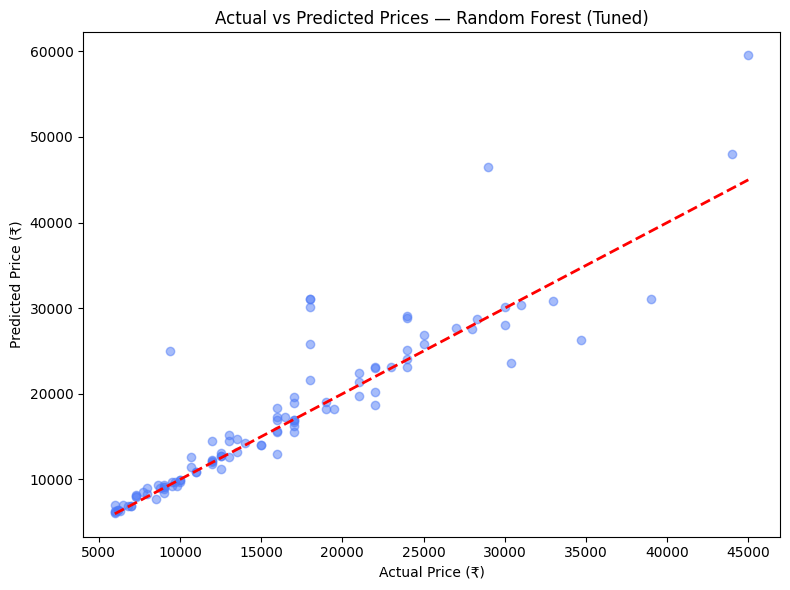

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, final_preds, alpha=0.5, color='#4F7BF7')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title('Actual vs Predicted Prices — Random Forest (Tuned)')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

In [ ]:
# Calculate predictions from the best model (Random Forest) on the preprocessed test data
final_preds = best_model.predict(X_test_preprocessed)

#SAVE MODEL

In [ ]:
import joblib

# Save the best model (Random Forest)
joblib.dump(best_model, 'mobile_price_model.pkl')

# Save the entire preprocessor pipeline
joblib.dump(preprocessor_pipe, 'feature_preprocessor.pkl')

print("\n✅ Model and preprocessor saved.")


✅ Model and preprocessor saved.


#**Final Insights & Recommendations**

This project successfully built a predictive model for mobile phone prices, offering valuable insights into the market dynamics and key features driving device valuation.

## **Key Insights:**

**Dominant Price Drivers:** The analysis clearly identifies Battery capacity and Front Camera quality (megapixels) as the two most significant factors influencing a mobile phone's price. This highlights consumer priorities beyond just core processing power.

**Performance Tiers Matter**: While less impactful than battery or front camera, Memory (RAM & Storage) and the Processor Tier remain crucial determinants, reflecting the market's demand for capable and responsive devices.

**5G as a Value Indicator:** The presence of 5G connectivity contributes positively to the price, indicating its status as a premium feature in the current market.

**Brand Premium:** Brand reputation and market positioning play a substantial role, with established premium brands consistently commanding higher average prices. However, feature value can still elevate prices across all brand tiers.

**Model Reliability:** The Random Forest Regressor demonstrated strong predictive capabilities (R² ~ 0.78, CV R² ~ 0.88), suggesting that the identified features are robust indicators of price.
Actionable Recommendations:

**Strategic Product Development:** Mobile phone manufacturers should prioritize advancements in battery technology and front-facing camera capabilities as these features have the highest leverage for influencing product pricing and consumer appeal.

**Tiered Feature Bundling:**  When designing different phone models or variants, consider how combinations of Memory, RAM, and Processor Tier can be bundled to target specific price segments effectively.

**Marketing & Communication Focus:** Highlight battery life, front camera prowess, and 5G connectivity prominently in marketing campaigns, as these are proven to resonate with price perception and consumer value.

**Competitive Pricing Analysis:** Utilize this model to benchmark new product pricing against competitors based on feature sets, ensuring competitive positioning while maximizing profitability.

**Continuous Monitoring:**  Regularly update the model with new data to capture evolving market trends, such as the emergence of new technologies (e.g., faster charging, display innovations) that could shift feature importance.

**Targeted Market Entry:** Brands aiming to enter higher price segments should focus heavily on differentiating through superior battery performance and front camera technology, alongside robust core specifications.
